In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully")

All libraries loaded successfully


In [4]:
df = pd.read_csv(
    'D:/Jar_Financial_Intelligence/data/raw/Customer_financial_profiles.csv',
    parse_dates=['date']
)

print(f"Rows: {df.shape[0]:,}")
print(f"columns: {df.shape[1]}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Unique clients: {df['client_id'].nunique():,}")

Rows: 20,000
columns: 21
Date range: 2023-01-01 to 2025-10-31
Unique clients: 4,941


In [8]:
print("=== COLUMN NAMES===")
print(df.columns.tolist())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== NULL VALUES ===")
print(df.isnull().sum())

print("\n=== DUPLICATE ROWS ===")
print(f"Duplicates: {df.duplicated().sum()}")


=== COLUMN NAMES===
['id', 'current_age', 'birth_year', 'birth_month', 'gender', 'address', 'per_capita_income', 'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards', 'transaction_id', 'date', 'client_id', 'card_id', 'amount', 'use_chip', 'merchant_id', 'merchant_city', 'merchant_state', 'zip']

=== DATA TYPES ===
id                            int64
current_age                   int64
birth_year                    int64
birth_month                   int64
gender                       object
address                      object
per_capita_income             int64
yearly_income                 int64
total_debt                    int64
credit_score                  int64
num_credit_cards              int64
transaction_id                int64
date                 datetime64[ns]
client_id                    object
card_id                      object
amount                      float64
use_chip                     object
merchant_id                  object
merchant_city          

In [9]:
print("==== FIRST 5 ROWS ====")
df.head()

==== FIRST 5 ROWS ====


,id,current_age,birth_year,birth_month,gender,address,per_capita_income,yearly_income,total_debt,credit_score,...,transaction_id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip
0,1,64,1961,3,Female,"Street 286, Indore, Madhya Pradesh - 452645",86125,1033501,280435,715,...,1251,2024-03-28,CLTIND00104,CRD001042,1483.94,Yes,MCH00496,Mumbai,Maharashtra,452645
1,2,39,1986,12,Female,"Street 268, Kolkata, West Bengal - 700555",68414,820965,0,834,...,9976,2025-09-20,CLTIND00213,CRD002132,1274.72,Yes,MCH00374,Mumbai,Maharashtra,700555
2,3,50,1975,7,Female,"Street 262, Lucknow, Uttar Pradesh - 226797",22595,271138,0,609,...,6084,2024-10-02,CLTIND03292,CRD032922,7622.04,No,MCH00108,Kolkata,West Bengal,226797
3,4,27,1998,2,Male,"Street 265, Nagpur, Maharashtra - 440623",24158,289898,0,782,...,3350,2023-09-02,CLTIND05205,CRD052053,3970.48,Yes,MCH00001,Indore,Madhya Pradesh,440623
4,5,45,1980,7,Other,"Street 157, Delhi, Delhi - 110965",45475,545697,117821,608,...,11725,2025-05-25,CLTIND04910,CRD049101,418.45,No,MCH00254,Bengaluru,Karnataka,110965


In [10]:
print("==== STATISTICAL SUMMARY ====")
df.describe()


==== STATISTICAL SUMMARY ====


,id,current_age,birth_year,birth_month,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,transaction_id,date,amount,zip
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04,2.000000e+04,20000.000000,20000.000000,20000.000000,20000,20000.000000,20000.000000
mean,10000.500000,44.210100,1980.789900,6.479150,61234.419700,7.348131e+05,1.345380e+05,702.979750,2.873750,10015.488700,2024-05-29 15:25:16.320000,3082.286901,445976.994400
min,1.000000,19.000000,1955.000000,1.000000,12500.000000,1.500000e+05,0.000000e+00,421.000000,1.000000,1.000000,2023-01-01 00:00:00,105.160000,110102.000000
25%,5000.750000,31.000000,1968.000000,3.000000,35671.000000,4.280470e+05,0.000000e+00,648.000000,2.000000,4971.000000,2023-09-14 00:00:00,1531.182500,380703.500000
50%,10000.500000,44.000000,1981.000000,7.000000,54896.000000,6.587560e+05,8.250300e+04,699.000000,3.000000,10026.500000,2024-05-28 00:00:00,2601.650000,440388.000000
75%,15000.250000,57.000000,1994.000000,10.000000,74842.000000,8.981090e+05,2.008720e+05,757.000000,4.000000,15062.750000,2025-02-13 00:00:00,4116.155000,560252.000000
max,20000.000000,70.000000,2006.000000,12.000000,250000.000000,3.000000e+06,1.817384e+06,900.000000,5.000000,20000.000000,2025-10-31 00:00:00,19806.630000,800988.000000
std,5773.647028,14.992515,14.992515,3.459532,35354.273099,4.242512e+05,1.739757e+05,76.993944,1.162574,5802.389323,NaN,2117.081361,168230.579911


In [11]:
print("=== GENDER ===")
print(df['gender'].value_counts())

print("\n=== USE CHIP ===")
print(df['use_chip'].value_counts())

print("\n=== TOP 10 CITIES ===")
print(df['merchant_city'].value_counts().head(10))

print("\n=== TOP 10 STATES ===")
print(df['merchant_state'].value_counts().head(10))

print("\n=== AGE RANGE ===")
print(f"Min age: {df['current_age'].min()}")
print(f"Max age: {df['current_age'].max()}")
print(f"Avg age: {df['current_age'].mean():.1f}")

=== GENDER ===
gender
Male      9855
Female    9479
Other      666
Name: count, dtype: int64

=== USE CHIP ===
use_chip
Yes    13927
No      6073
Name: count, dtype: int64

=== TOP 10 CITIES ===
merchant_city
Surat        1761
Bengaluru    1567
Pune         1442
Lucknow      1435
Indore       1384
Nagpur       1365
Hyderabad    1352
Mumbai       1325
Patna        1311
Jaipur       1288
Name: count, dtype: int64

=== TOP 10 STATES ===
merchant_state
Maharashtra       4132
Gujarat           3043
Madhya Pradesh    2584
Karnataka         1567
Uttar Pradesh     1435
Telangana         1352
Bihar             1311
Rajasthan         1288
Tamil Nadu        1284
Delhi             1079
Name: count, dtype: int64

=== AGE RANGE ===
Min age: 19
Max age: 70
Avg age: 44.2


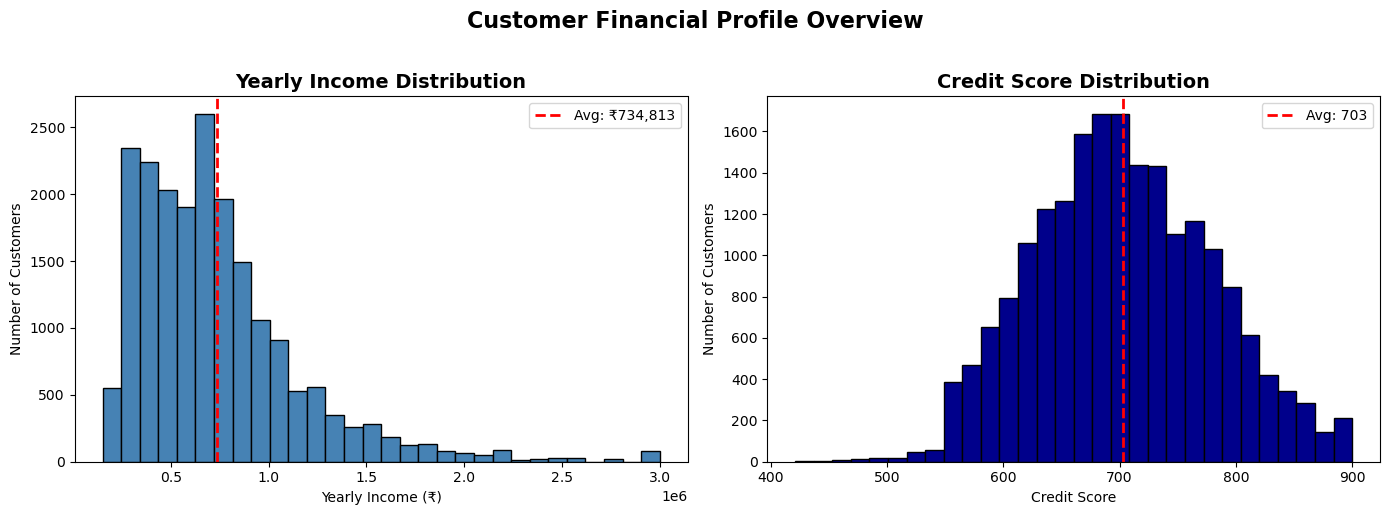

✅ Chart saved


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Yearly Income Distribution
axes[0].hist(df['yearly_income'], bins=30, 
             color='steelblue', edgecolor='black')
axes[0].set_title('Yearly Income Distribution', 
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Yearly Income (₹)')
axes[0].set_ylabel('Number of Customers')
axes[0].axvline(df['yearly_income'].mean(), 
                color='red', linestyle='--', linewidth=2,
                label=f"Avg: ₹{df['yearly_income'].mean():,.0f}")
axes[0].legend()

# Chart 2 — Credit Score Distribution
axes[1].hist(df['credit_score'], bins=30,
             color='darkblue', edgecolor='black')
axes[1].set_title('Credit Score Distribution',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Credit Score')
axes[1].set_ylabel('Number of Customers')
axes[1].axvline(df['credit_score'].mean(),
                color='red', linestyle='--', linewidth=2,
                label=f"Avg: {df['credit_score'].mean():.0f}")
axes[1].legend()

plt.suptitle('Customer Financial Profile Overview',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('D:/Jar_Financial_Intelligence/dashboard/chart1_income_credit.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved")

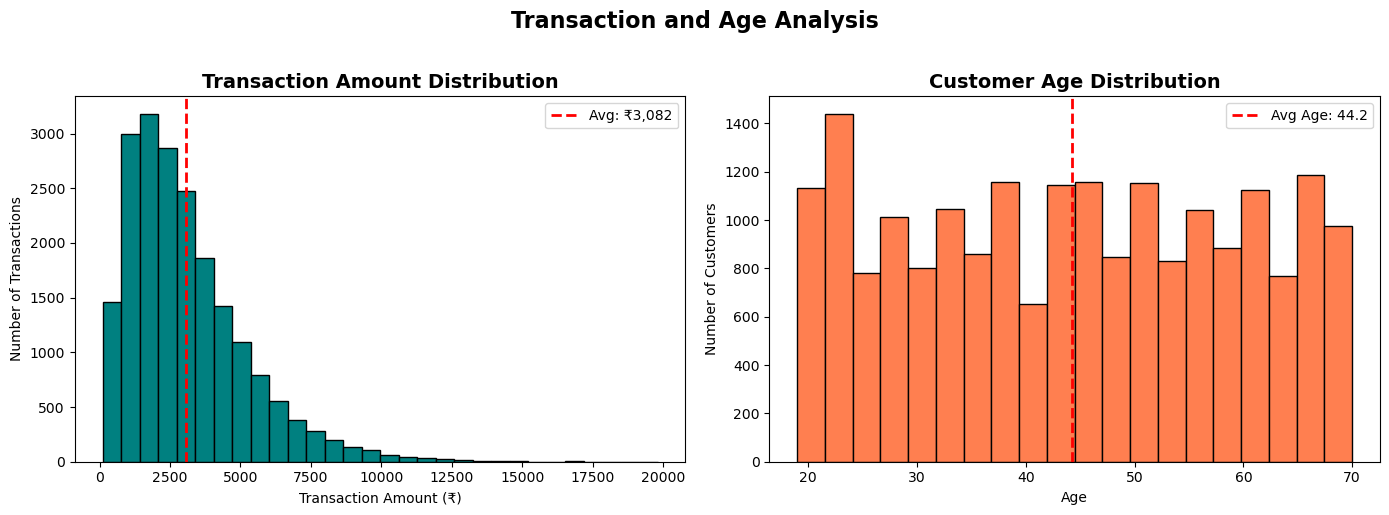

✅ Chart saved


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Transaction Amount Distribution
axes[0].hist(df['amount'], bins=30,
             color='teal', edgecolor='black')
axes[0].set_title('Transaction Amount Distribution',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Transaction Amount (₹)')
axes[0].set_ylabel('Number of Transactions')
axes[0].axvline(df['amount'].mean(),
                color='red', linestyle='--', linewidth=2,
                label=f"Avg: ₹{df['amount'].mean():,.0f}")
axes[0].legend()

# Chart 2 — Age Distribution
axes[1].hist(df['current_age'], bins=20,
             color='coral', edgecolor='black')
axes[1].set_title('Customer Age Distribution',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Number of Customers')
axes[1].axvline(df['current_age'].mean(),
                color='red', linestyle='--', linewidth=2,
                label=f"Avg Age: {df['current_age'].mean():.1f}")
axes[1].legend()

plt.suptitle('Transaction and Age Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('D:/Jar_Financial_Intelligence/dashboard/chart2_amount_age.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved")

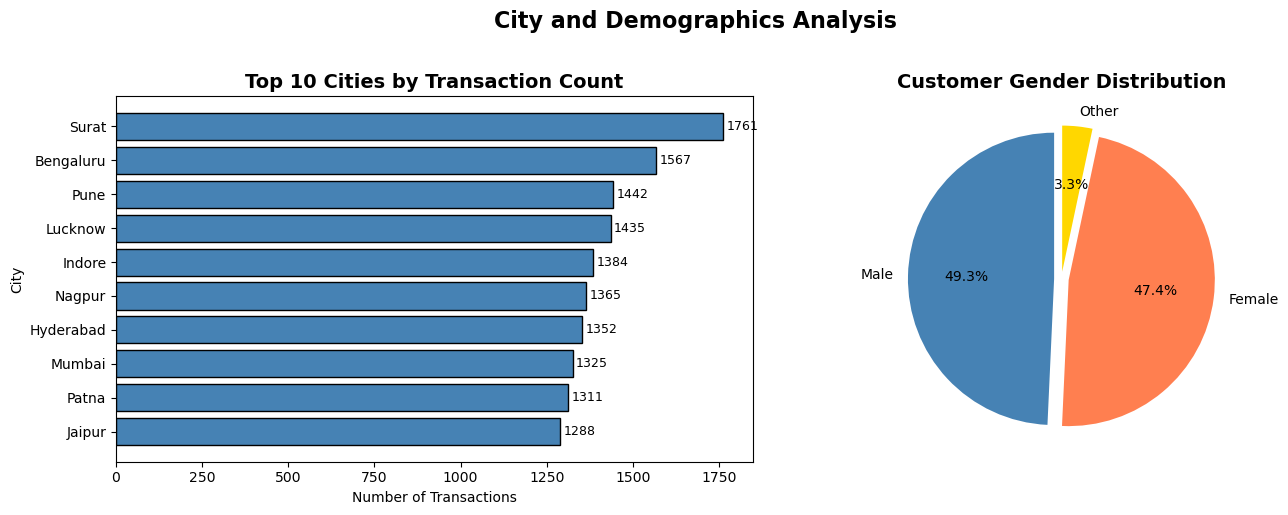

✅ Chart saved


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Top 10 Cities by Transaction Count
city_counts = df['merchant_city'].value_counts().head(10)
axes[0].barh(city_counts.index[::-1], 
             city_counts.values[::-1],
             color='steelblue', edgecolor='black')
axes[0].set_title('Top 10 Cities by Transaction Count',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Transactions')
axes[0].set_ylabel('City')
for i, v in enumerate(city_counts.values[::-1]):
    axes[0].text(v + 10, i, str(v), va='center', fontsize=9)

# Chart 2 — Gender Distribution
gender_counts = df['gender'].value_counts()
colors = ['steelblue', 'coral', 'gold']
axes[1].pie(gender_counts.values,
            labels=gender_counts.index,
            autopct='%1.1f%%',
            colors=colors,
            startangle=90,
            explode=[0.05, 0.05, 0.05])
axes[1].set_title('Customer Gender Distribution',
                   fontsize=14, fontweight='bold')

plt.suptitle('City and Demographics Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('D:/Jar_Financial_Intelligence/dashboard/chart3_city_gender.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved")

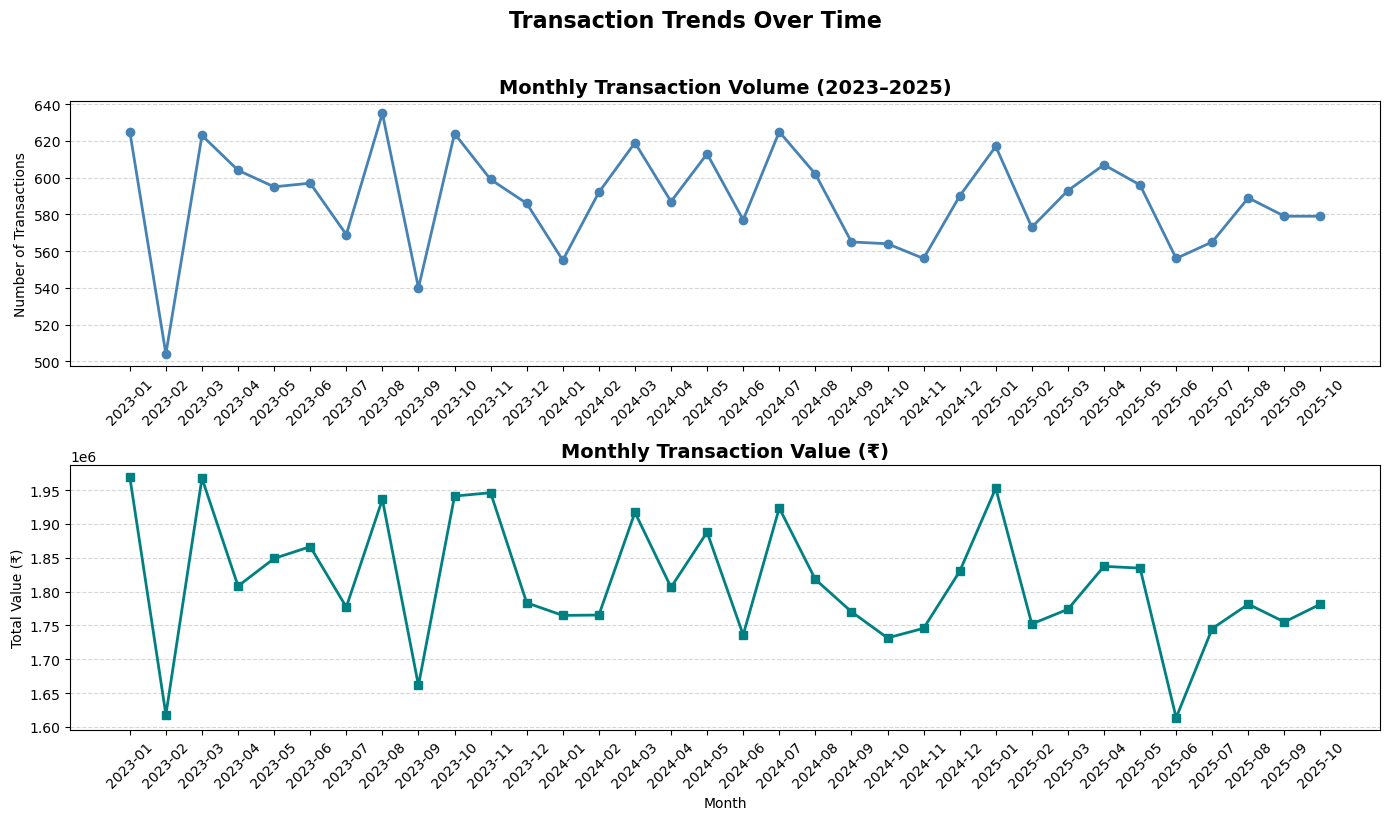

✅ Chart saved


In [17]:
# Group by month and year
monthly = df.groupby(
    [df['date'].dt.year.rename('year'), 
     df['date'].dt.month.rename('month')]
).agg(
    txn_count  = ('transaction_id', 'count'),
    total_value= ('amount', 'sum'),
    avg_value  = ('amount', 'mean')
).reset_index()

# Create a readable date label
monthly['month_label'] = (
    monthly['year'].astype(str) + '-' +
    monthly['month'].astype(str).str.zfill(2)
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Chart 1 — Monthly Transaction Count
axes[0].plot(monthly['month_label'],
             monthly['txn_count'],
             marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Monthly Transaction Volume (2023–2025)',
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Chart 2 — Monthly Total Value
axes[1].plot(monthly['month_label'],
             monthly['total_value'],
             marker='s', color='teal', linewidth=2)
axes[1].set_title('Monthly Transaction Value (₹)',
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('Total Value (₹)')
axes[1].set_xlabel('Month')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Transaction Trends Over Time',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('D:/Jar_Financial_Intelligence/dashboard/chart4_monthly_trend.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved")

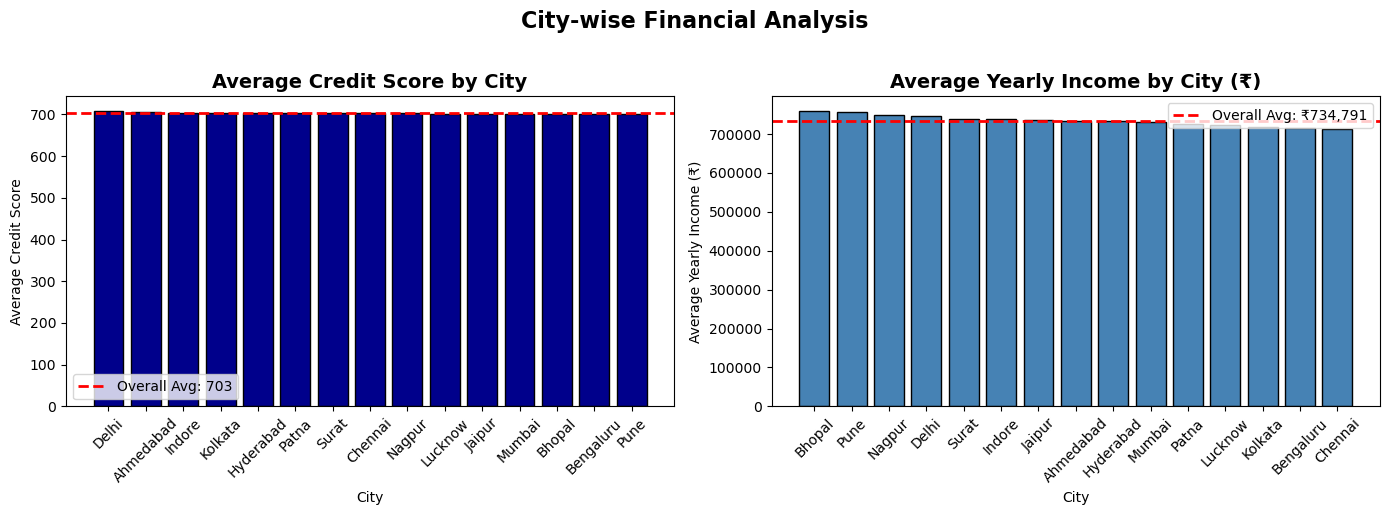

✅ Chart saved


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Average Credit Score by City
city_credit = df.groupby('merchant_city')['credit_score'].mean().sort_values(ascending=False)
axes[0].bar(city_credit.index, city_credit.values,
            color='darkblue', edgecolor='black')
axes[0].set_title('Average Credit Score by City',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Average Credit Score')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(city_credit.mean(),
                color='red', linestyle='--', linewidth=2,
                label=f"Overall Avg: {city_credit.mean():.0f}")
axes[0].legend()

# Chart 2 — Average Yearly Income by City
city_income = df.groupby('merchant_city')['yearly_income'].mean().sort_values(ascending=False)
axes[1].bar(city_income.index, city_income.values,
            color='steelblue', edgecolor='black')
axes[1].set_title('Average Yearly Income by City (₹)',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Average Yearly Income (₹)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(city_income.mean(),
                color='red', linestyle='--', linewidth=2,
                label=f"Overall Avg: ₹{city_income.mean():,.0f}")
axes[1].legend()

plt.suptitle('City-wise Financial Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('D:/Jar_Financial_Intelligence/dashboard/chart5_city_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved")

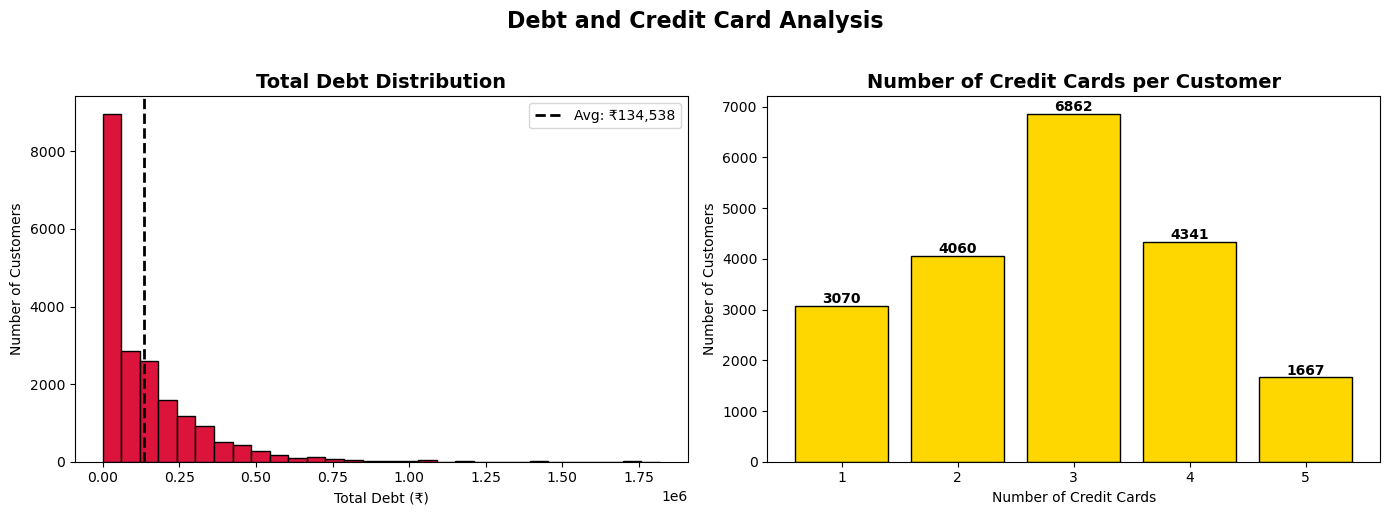

✅ Chart saved


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Total Debt Distribution
axes[0].hist(df['total_debt'], bins=30,
             color='crimson', edgecolor='black')
axes[0].set_title('Total Debt Distribution',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Debt (₹)')
axes[0].set_ylabel('Number of Customers')
axes[0].axvline(df['total_debt'].mean(),
                color='black', linestyle='--', linewidth=2,
                label=f"Avg: ₹{df['total_debt'].mean():,.0f}")
axes[0].legend()

# Chart 2 — Number of Credit Cards Distribution
card_counts = df['num_credit_cards'].value_counts().sort_index()
axes[1].bar(card_counts.index, card_counts.values,
            color='gold', edgecolor='black')
axes[1].set_title('Number of Credit Cards per Customer',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Credit Cards')
axes[1].set_ylabel('Number of Customers')
for i, v in enumerate(card_counts.values):
    axes[1].text(card_counts.index[i], v + 50,
                 str(v), ha='center', fontsize=10,
                 fontweight='bold')

plt.suptitle('Debt and Credit Card Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('D:/Jar_Financial_Intelligence/dashboard/chart6_debt_cards.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved")

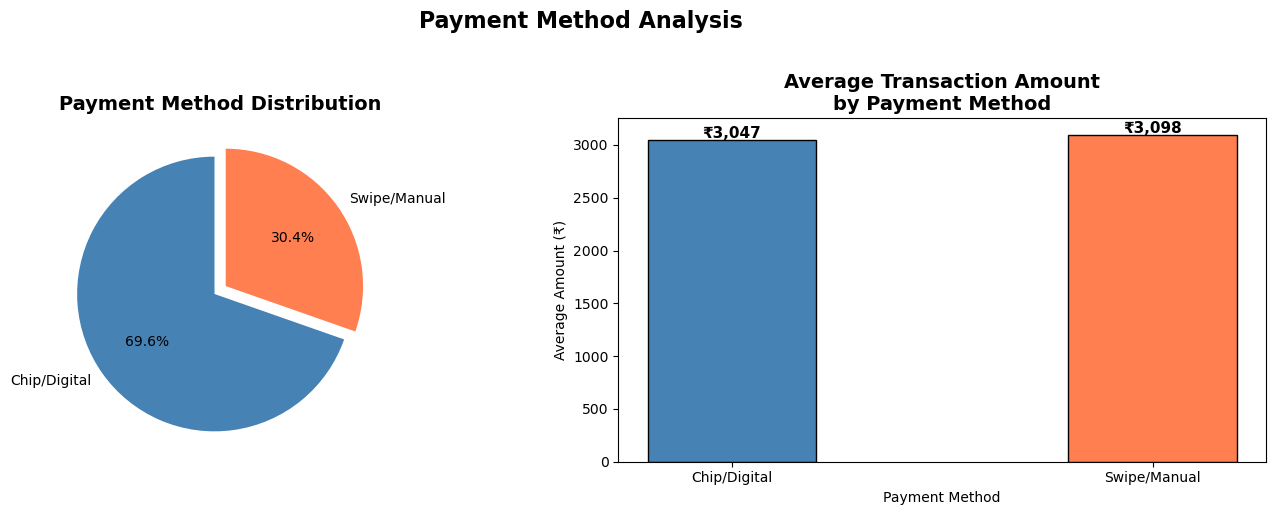

✅ Chart saved


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Chip vs Non-Chip Transactions
chip_counts = df['use_chip'].value_counts()
colors = ['steelblue', 'coral']
axes[0].pie(chip_counts.values,
            labels=['Chip/Digital', 'Swipe/Manual'],
            autopct='%1.1f%%',
            colors=colors,
            startangle=90,
            explode=[0.05, 0.05])
axes[0].set_title('Payment Method Distribution',
                   fontsize=14, fontweight='bold')

# Chart 2 — Average Amount by Payment Method
chip_avg = df.groupby('use_chip')['amount'].mean()
chip_avg.index = ['Chip/Digital', 'Swipe/Manual']
axes[1].bar(chip_avg.index, chip_avg.values,
            color=['steelblue', 'coral'],
            edgecolor='black', width=0.4)
axes[1].set_title('Average Transaction Amount\nby Payment Method',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Payment Method')
axes[1].set_ylabel('Average Amount (₹)')
for i, v in enumerate(chip_avg.values):
    axes[1].text(i, v + 20, f"₹{v:,.0f}",
                 ha='center', fontsize=11,
                 fontweight='bold')

plt.suptitle('Payment Method Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('D:/Jar_Financial_Intelligence/dashboard/chart7_payment_method.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved")

## Key Insights from Exploratory Data Analysis

### Dataset Overview
- 20,000 transactions from 4,941 unique clients across 15 Indian cities
- Date range: January 2023 to October 2025 (2.8 years)
- Zero null values and zero duplicates — clean dataset

### Customer Demographics
- Age range: 19 to 70 years — average age 44.2 years
- Gender split: Male 49.3%, Female 47.4%, Other 3.3%
- Predominantly working-age population — Jar's core target segment

### Financial Health
- Income range: ₹1.5 lakh to ₹30 lakh — avg ₹7.3 lakh/year
- Credit score range: 421 to 900 — avg 703 (Good tier)
- Average total debt: ₹1.35 lakh — debt-to-income ratio is manageable
- Average number of credit cards: 2.9 per customer

### Transaction Patterns
- Transaction range: ₹105 to ₹19,807 — avg ₹3,082
- Digital payment adoption: 69.6% use chip/digital payments
- Maharashtra leads with 4,132 transactions — highest volume state
- Surat is the top city with 1,761 transactions

### Business Implications for Jar
- Customers with avg income ₹7.3L and avg debt ₹1.35L have
  significant monthly savings capacity
- High digital payment adoption (69.6%) indicates tech-savvy users
  — ideal for a fintech savings platform like Jar
- Good average credit score (703) suggests financially responsible
  users with genuine savings potential

In [21]:
# Create a summary statistics file
# This documents your EDA findings permanently

summary = {
    'Total Transactions':        len(df),
    'Unique Clients':            df['client_id'].nunique(),
    'Unique Cities':             df['merchant_city'].nunique(),
    'Unique States':             df['merchant_state'].nunique(),
    'Date Range Start':          str(df['date'].min().date()),
    'Date Range End':            str(df['date'].max().date()),
    'Avg Yearly Income':         round(df['yearly_income'].mean(), 2),
    'Avg Credit Score':          round(df['credit_score'].mean(), 2),
    'Avg Transaction Amount':    round(df['amount'].mean(), 2),
    'Avg Total Debt':            round(df['total_debt'].mean(), 2),
    'Avg Num Credit Cards':      round(df['num_credit_cards'].mean(), 2),
    'Digital Payment %':         round(
        (df['use_chip'] == 'Yes').mean() * 100, 2),
    'Male %':                    round(
        (df['gender'] == 'Male').mean() * 100, 2),
    'Female %':                  round(
        (df['gender'] == 'Female').mean() * 100, 2),
    'Null Values':               int(df.isnull().sum().sum()),
    'Duplicate Rows':            int(df.duplicated().sum()),
    'Top City':                  df['merchant_city'].value_counts().index[0],
    'Top State':                 df['merchant_state'].value_counts().index[0],
}

summary_df = pd.DataFrame(
    list(summary.items()),
    columns=['Metric', 'Value']
)

# Save to processed folder
summary_df.to_csv(
    'D:/Jar_Financial_Intelligence/data/processed/eda_summary.csv',
    index=False
)

print("=== EDA SUMMARY ===")
print(summary_df.to_string(index=False))
print("\n✅ Summary saved to data/processed/eda_summary.csv")

=== EDA SUMMARY ===
                Metric       Value
    Total Transactions       20000
        Unique Clients        4941
         Unique Cities          15
         Unique States          11
      Date Range Start  2023-01-01
        Date Range End  2025-10-31
     Avg Yearly Income   734813.05
      Avg Credit Score      702.98
Avg Transaction Amount     3082.29
        Avg Total Debt   134537.99
  Avg Num Credit Cards        2.87
     Digital Payment %       69.64
                Male %       49.28
              Female %        47.4
           Null Values           0
        Duplicate Rows           0
              Top City       Surat
             Top State Maharashtra

✅ Summary saved to data/processed/eda_summary.csv


In [7]:
print(df.duplicated().sum())

0
